## <b>Domain Decomposition Conformity Check</b>

Window function evaluations must be conformed with **partition of unity** for domain decomposed SWIM-PDE models at **each level**. Here we will visualize the window function evaluations for a 1D problem for **multilevel SWIM-PDE** model to perform **conformity check**.

In [1]:
import os
import sys
root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
print(root)
sys.path.append(root)

c:\Users\dogak\OneDrive\Belgeler\swim-pde-thesis


In [2]:
from swimpde_jax.domain.visualizer import visualize_window_functions
from swimpde_jax.domain import DecomposedDomain, MultiLevelDecomposedDomain
import jax.numpy as jnp

In [3]:
# Parameter definitions
SPAN = 0, 10
N_DIM = 1
N_POINTS = 250
NUM_PARTITION = [2, 4, 8]
OVERLAP_RATIO = 1.9
WINDOW_FN = "gaussian"

# Sampling the points within the problem domains
points = jnp.linspace(*SPAN, N_POINTS).reshape(-1, N_DIM)

# Boundary
boundary_mask = (
    (points[:, 0] == SPAN[0]) |
    (points[:, 0] == SPAN[1])
)
        
# Instance definitions
domain = MultiLevelDecomposedDomain(
    interior_points=points,
    boundary_points=None,
    num_partition_per_level=NUM_PARTITION,
    overlap_ratio=OVERLAP_RATIO, 
    window_fn=WINDOW_FN
)

### Evaluation

From the obtained Figures below that shows normalized window function evaluations, it can be seen that at each level Partition of Unity holds. 

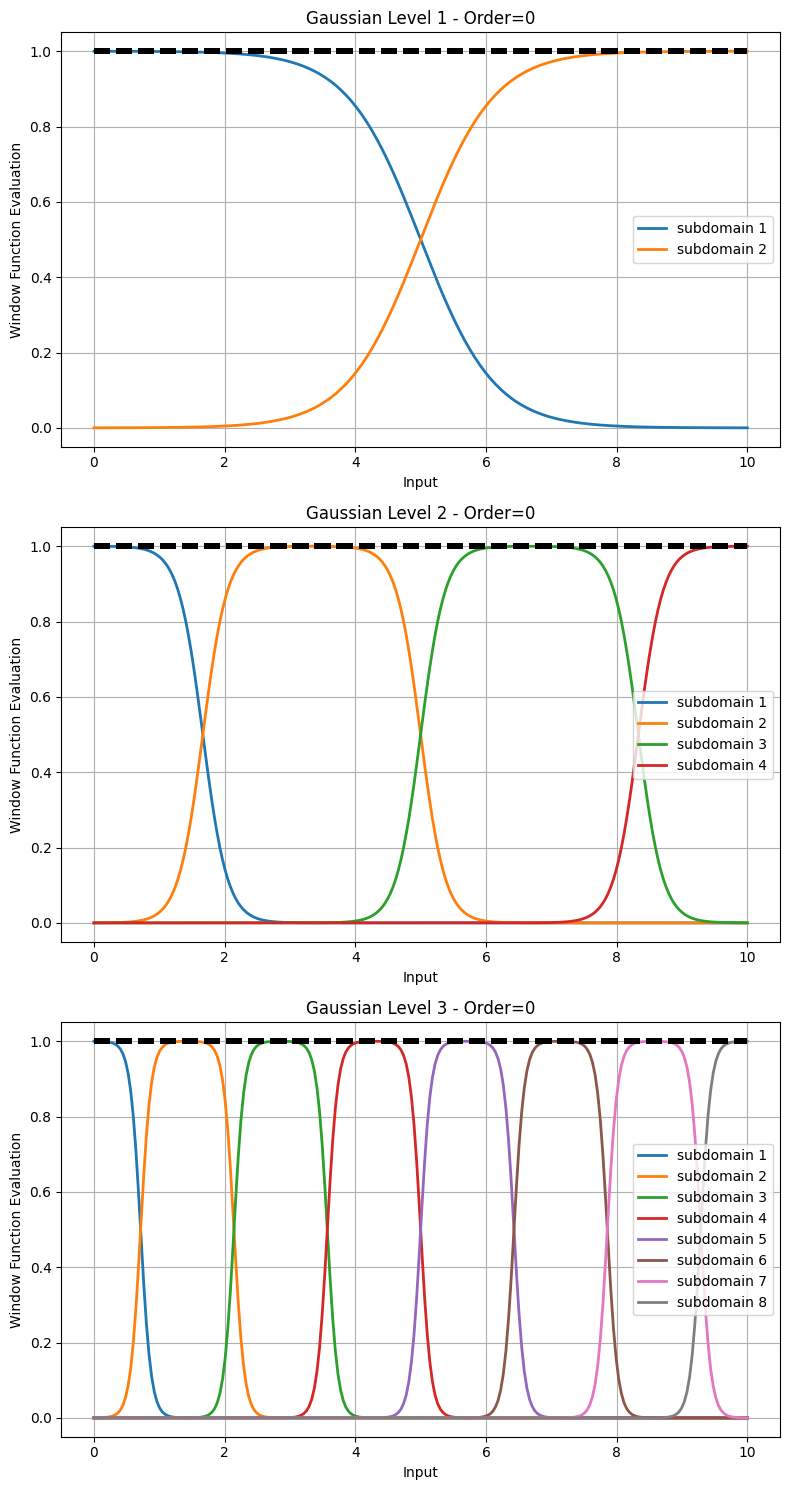

In [4]:
visualize_window_functions(domain, normalized=True, show=True, legend=True)

### Additional Info

Additionally unnormalized window function evaluations are given below to highlight the characteristics of the used gaussian window function.

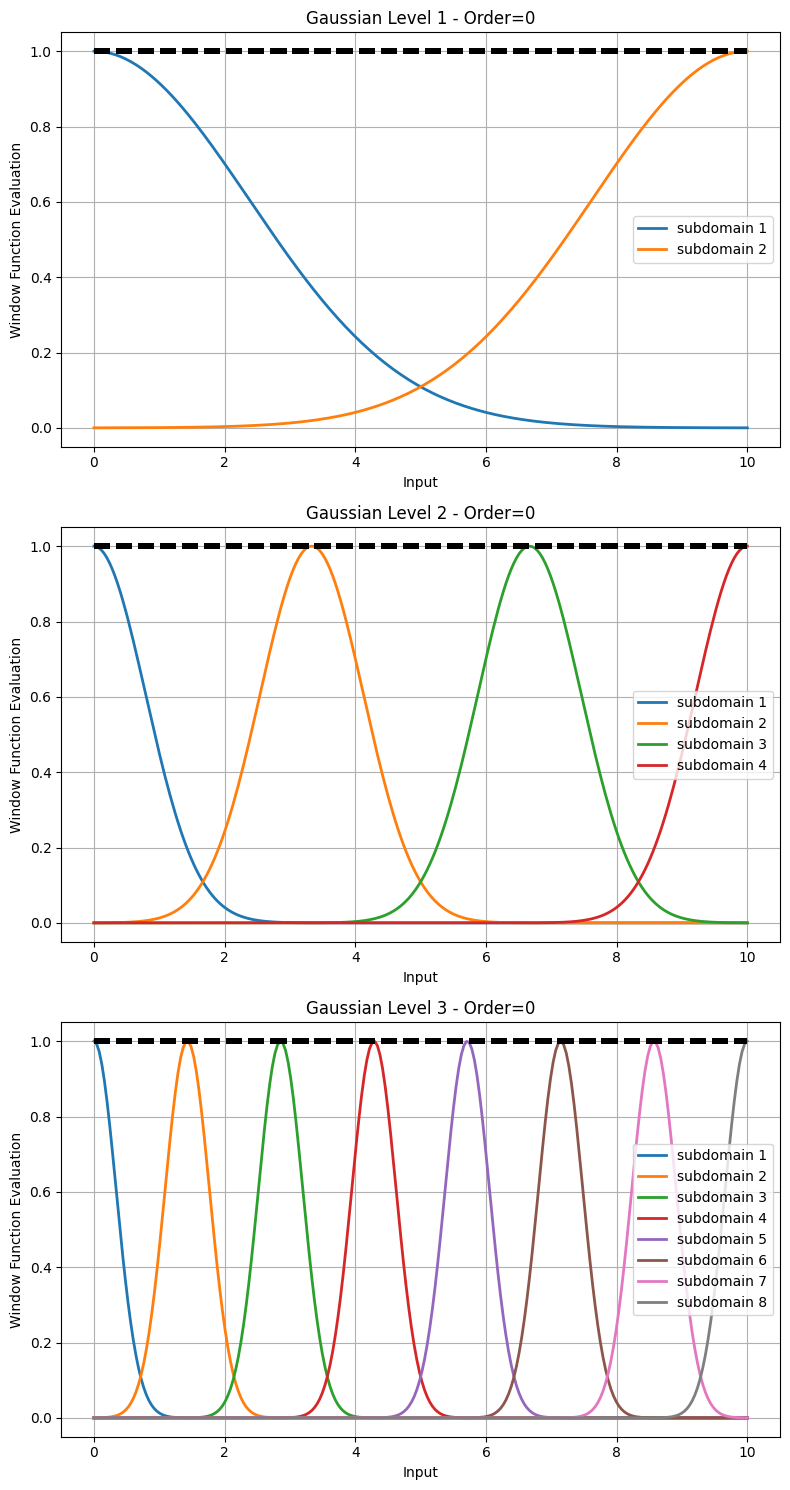

In [5]:
visualize_window_functions(domain, normalized=False, show=True, legend=True)